<a href="https://colab.research.google.com/github/NataMaru/ML_for_people_tasks/blob/main/HW_2_2_%D0%9F%D0%BE%D0%BB%D1%96%D0%BD%D0%BE%D0%BC%D1%96%D0%B0%D0%BB%D1%8C%D0%BD%D1%96_%D0%BE%D0%B7%D0%BD%D0%B0%D0%BA%D0%B8_Pipelines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми проведемо додаткові експерименти для рішення задачі бінарної класифікації і створимо ваш новий submission на змагання на Kaggle.

-----------


**Завдання 0**. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle)  Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").


**Завдання 1**. **Збираємо весь код з попереднього ДЗ в одному місці.** В лекційному ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb` ми познайомились з поняттям пайплайнів, а також я показала, як компактно виглядає рішення МЛ задачі, якщо ми зберемо весь код разом.

Оскільки ми далі будемо робити експерименти, які включають ті самі етапи попередньої обробки, але інше моделювання - буде зручно мати весь код компактно і під рукою. Тому зараз ми займемось збором коду до купи :) Після цього завдання для подальших експериментів ви можете перенести частини розвʼязку взагалі в окремий `.py` файл, аби було зручно імпортувати функції.

Зі свого рішення в попередньому домашньому завданні (`Логістична регресія з scikit learn.ipynb`) зберіть усі кроки розвʼязку задачі разом з використанням `sklearn.Pipeline` за прикладом з лекції.

Ваш код нижче має містити
1. Читання даних з файлу (поза пайплайном).
2. Розбиття на тренувальний і валідаційний набори, де валідаційний містить 20% даних (поза пайплайном).
3. Виділення категоріальних і числових колонок (поза пайплайном).
4. Підготовку категоріальних і числових колонок (частина пайплайну). В прикладі в лекції ми оформлювали обробку числових і категоріальних колонок в окремі трансформери `numeric_transformer`, `categorical_cols`. Рекоемндую зробити саме так, так потім зручніше вносити зміни :)
5. Тренування лог регресії (частина пайплайну).
6. Запуск пайплайну на тренування на трен. даних (поза пайплайном).
7. Запуск пайплайну на передбачення на трен і вал. даних і вимір метрик якості ROC-AUC + вивдення Confusion Matrix (поза пайплайном).
8. Збереження моделі в формат joblib (поза пайплайном).

Ви це все вже зробили в попереднтьому ДЗ! Тож, тут просто заадча все зібрати разом.

Нижче я додала підказки, що покроково ви маєте зробити. Якщо ви почуваєтесь впевнено, можете видалити ці підказки і реалізувати все самостійно, або ж - просто заповнити пропуски.

Завдання оцінюється в 10 балів. Головний результат - аби код в фіналі був робочий. Бо за не робочий нам гроші ніхто не заплатить :)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")
from sklearn.metrics import classification_report,roc_curve, auc,f1_score,accuracy_score,confusion_matrix,root_mean_squared_error
from sklearn.linear_model import LogisticRegression,LinearRegression,Ridge, Lasso, ElasticNet
from sklearn.preprocessing import OneHotEncoder,StandardScaler,PolynomialFeatures
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import joblib


In [2]:

raw_df = pd.read_csv('train.csv', index_col=0)

train_df, val_df = train_test_split(raw_df, test_size=0.2, random_state=42,stratify=raw_df['Exited'])
# Створюємо трен. і вал. набори
input_cols=list(raw_df.columns)[2:-1]
target_col='Exited'
train_inputs=train_df[input_cols].copy()
train_targets=train_df[target_col].copy()
val_inputs=val_df[input_cols].copy()
val_targets=val_df[target_col].copy()

# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()


In [3]:

# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear'))
])


# Тренуємо пайплайн
model_pipeline.fit(train_inputs, train_targets)

# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(model_pipeline, inputs, targets, name=''):
    preds = model_pipeline.predict(inputs)
    y_pred_proba = model_pipeline.predict_proba(inputs)[:, 1]
    f1 = f1_score(targets, preds)
    print("F1 score: {:.2f}%".format(f1))
    fpr, tpr, thresholds = roc_curve(targets, y_pred_proba)

    # Compute AUROC
    roc_auc = auc(fpr, tpr)
    print(f"Area under ROC score on {name} dataset: {roc_auc:.2f}%")
    confusion_matrix_ = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(confusion_matrix_, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()
    return preds


F1 score: 0.64%
Area under ROC score on Train dataset: 0.88%


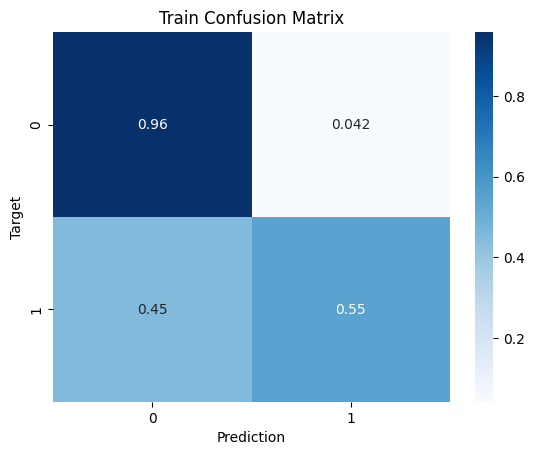

F1 score: 0.64%
Area under ROC score on Validation dataset: 0.88%


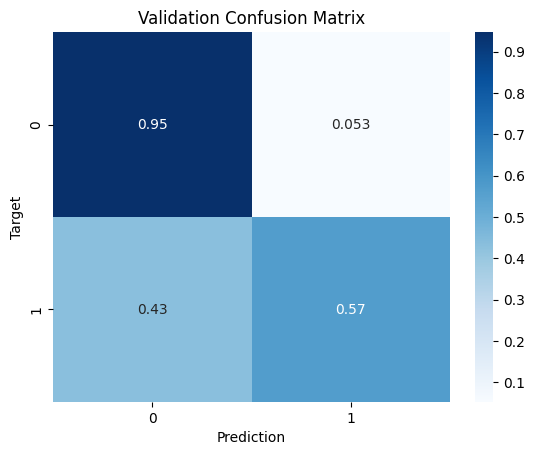

['bank_churn.joblib']

In [4]:
# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(model_pipeline,train_inputs, train_targets, 'Train')
val_preds = predict_and_plot(model_pipeline,val_inputs, val_targets, 'Validation')


# Зберігаємо модель для подальшого використання
joblib.dump(model_pipeline, 'bank_churn.joblib')



**Завдання 2**. Такс, у нас з вами є вже готовий пайплайн. Давайте проведемо нові експерименти.

  Додайте в попередню обробку числових колонок генерацію polinomal features до степені 2 включно. Для цього створіть новий препроцесор і створіть новий пайплайн.

  Запустіть пайплайн на тренування і виведіть метрики для тренувального і валідаційного набору. Напишіть, як вам модель? Чи спостерігається в цій моделі overfit чи underfit? Чи ця модель добре генералізує?

In [6]:
model_pipeline_poly_2 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('poly', PolynomialFeatures(degree=2)),
    ('classifier', LogisticRegression(solver='liblinear'))
])


In [7]:
# Тренуємо пайплайн
model_pipeline_poly_2.fit(train_inputs, train_targets)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['CreditScore', 'Age',
                                                   'Tenure', 'Balance',
                                                   'NumOfProducts', 'HasCrCard',
                                                   'IsActiveMember',
                                                   'EstimatedSalary']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Geography', 'Gender'])])),
                ('poly', PolynomialFeatures()),
                ('classifier', LogisticRegression(solver='liblinear'))])

F1 score: 0.74%
Area under ROC score on Train dataset: 0.93%


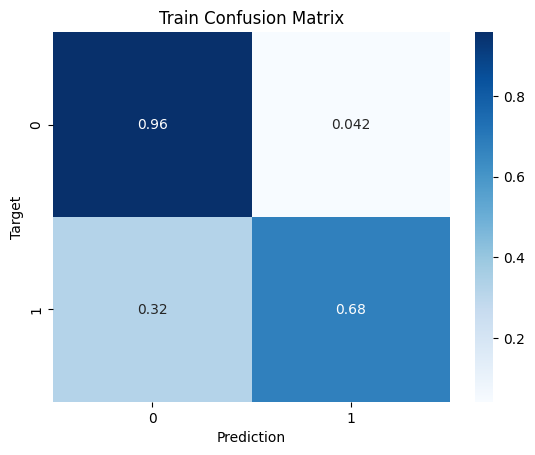

F1 score: 0.72%
Area under ROC score on Validation dataset: 0.93%


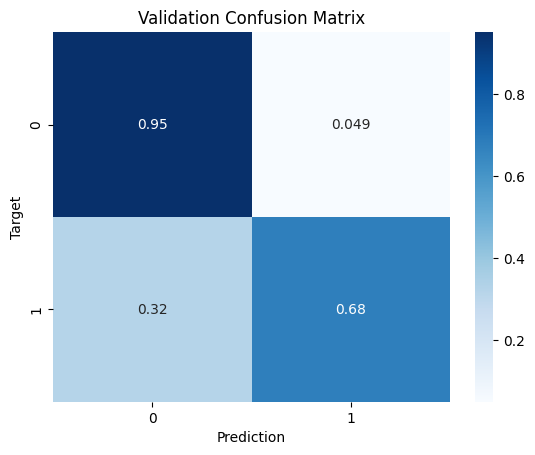

In [8]:
# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(model_pipeline_poly_2,train_inputs, train_targets, 'Train')
val_preds = predict_and_plot(model_pipeline_poly_2,val_inputs, val_targets, 'Validation')

**Завдання 3**. Тепер давайте створимо ще новий пайплайн, тільки тепер поліноміальні ознаки згенеруємо до степені 4. Зробіть висновок про якість моделі. Якщо вам подобається резульат якоїсь з моделей в цьому ДЗ - рекомендую зробити submission в змаганні.

In [9]:
model_pipeline_poly_4 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('poly', PolynomialFeatures(degree=4)),
    ('classifier', LogisticRegression(solver='liblinear'))
])


In [10]:
# Тренуємо пайплайн
model_pipeline_poly_4.fit(train_inputs, train_targets)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['CreditScore', 'Age',
                                                   'Tenure', 'Balance',
                                                   'NumOfProducts', 'HasCrCard',
                                                   'IsActiveMember',
                                                   'EstimatedSalary']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Geography', 'Gender'])])),
                ('poly', PolynomialFeatures(degree=4)),
                ('classifier', LogisticRegression(solver='liblinear'))])

F1 score: 0.79%
Area under ROC score on Train dataset: 0.96%


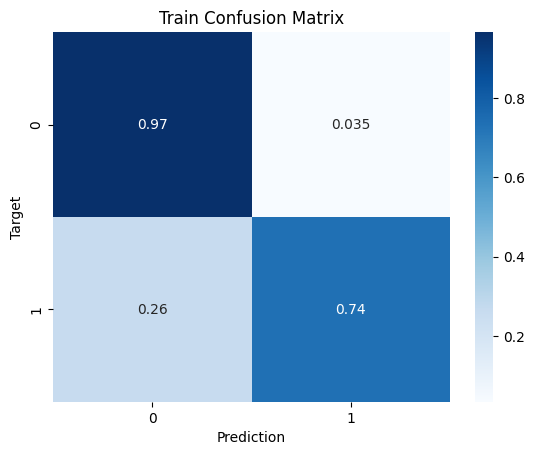

F1 score: 0.69%
Area under ROC score on Validation dataset: 0.90%


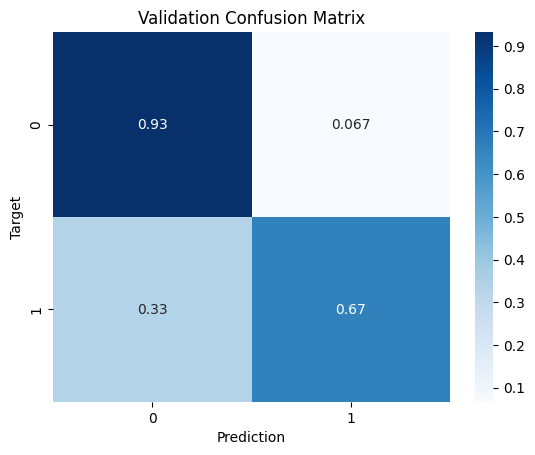

In [11]:
# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(model_pipeline_poly_4,train_inputs, train_targets, 'Train')
val_preds = predict_and_plot(model_pipeline_poly_4,val_inputs, val_targets, 'Validation')

In [12]:
#переррахунок для змагань
#raw_df_test = pd.read_csv('test.csv')

#raw_df_test = raw_df_test.drop(['CustomerId', 'Surname'], axis=1)
# Створюємо трен. і вал. набори
#input_cols=list(raw_df_test.columns)
#test_inputs=raw_df_test[input_cols].copy()


# Виявляємо числові і категоріальні колонки
#numeric_cols = test_inputs.select_dtypes(include=np.number).columns.tolist()
#categorical_cols = test_inputs.select_dtypes('object').columns.tolist()
#test_proba = model_pipeline_poly_2.predict_proba(test_inputs)[:, 1]
#raw_df_test['Exited']=model_pipeline_poly_2.predict_proba(test_inputs)[:, 1]
#sample_submission  = pd.read_csv('sample_submission.csv')
#sample_submission['Exited'] = sample_submission['id'].map(raw_df_test.set_index('id')['Exited'])
#sample_submission.to_csv('sample_submission.csv', index=False)

**Завдання 4. Перенавчання і регуляризація**.

  Скачайте набір даних `regression_data.csv`. Звичайте набір даних з `regression_data.csv`, розбийте на train і test (в тест 20%) і натренуйте модель лінійної регресії з масштабуванням числових ознак і поліноміальними ознаками до степені **5 включно**.

  Виміряйте якість прогностичної моделі і зробіть висновок, чи модель хороша, чи вона добре генералізує?


In [14]:
regression_df = pd.read_csv('regression_data.csv')

regression_df.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,target
0,-0.190339,-1.382800,-0.875618,0.538910,-1.037246,28.938854
1,-0.321386,-0.563725,0.412931,-0.147057,-0.825497,-7.664581
2,2.122156,-1.519370,1.032465,-1.260884,0.917862,-63.845482
3,-1.380101,-0.055548,-1.703382,0.074095,1.628616,4.076259
4,-0.072829,-1.514847,-0.846794,0.714000,0.473238,34.879013


In [15]:
train_df, test_df = train_test_split(regression_df, test_size=0.2, random_state=42)
# Створюємо трен. і вал. набори
input_cols=list(regression_df.columns)[:-1]
target_col='target'

train_inputs=train_df[input_cols].copy()
train_targets=train_df[target_col].copy()
test_inputs=test_df[input_cols].copy()
test_targets=test_df[target_col].copy()

In [16]:


model_pipeline = Pipeline(steps=[
    ('poly', PolynomialFeatures(degree=5, include_bias=False)),

    ('scaler', StandardScaler()),

    ('regressor', LinearRegression())
])

model_pipeline.fit(train_inputs, train_targets)

Pipeline(steps=[('poly', PolynomialFeatures(degree=5, include_bias=False)),
                ('scaler', StandardScaler()),
                ('regressor', LinearRegression())])

In [17]:
def evaluate_model(model, train_inputs, train_targets, test_inputs, test_targets):
    y_train_pred = model.predict(train_inputs)
    y_test_pred = model.predict(test_inputs)

    train_metrics = root_mean_squared_error(train_targets, y_train_pred)
    test_metrics = root_mean_squared_error(test_targets, y_test_pred)

    return dict(train=train_metrics, test=test_metrics)

In [18]:
evaluate_model(model_pipeline, train_inputs, train_targets, test_inputs, test_targets)

{'train': 8.389570955674058e-14, 'test': 12.676697837159335}

###Висновки
модель перенавчена, оскільки помилка на тренувальних даних майже нуль а на тестових 12,68

**Завдання 5**. Натренуйте моделі Lasso(), Ridge(), ElasaticNet() на цих даних (з поліном ознаками до степені 20 включно), порівняйте якість з тою, яка була отримана з лінійною регресією. Яка модель найкраще генералізує і чому на ваш погляд (можливо треба буде для відповіді зробити додатковий аналіз ознак)?

In [25]:
# Список моделей для тестування
models = [
    ('Linear', LinearRegression()),
    ('Ridge', Ridge(alpha=0.5)),
    ('Lasso', Lasso(alpha=0.1)),
    ('ElasticNet', ElasticNet(alpha=0.5))
]

results = {}

for name, model in models:
    # Створюємо пайплайн для кожної моделі
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=20)),
        ('scaler', StandardScaler()),
        ('regressor', model)
    ])
    # Тренуємо та оцінюємо
    pipe.fit(train_inputs, train_targets)
    y_train_pred = pipe.predict(train_inputs)
    y_test_pred = pipe.predict(test_inputs)

    train_metrics = root_mean_squared_error(train_targets, y_train_pred)
    test_metrics = root_mean_squared_error(test_targets, y_test_pred)

    #кіл-ть не нульових коефіцієнтів
    coefs = pipe.named_steps['regressor'].coef_
    non_zero = np.sum(np.abs(coefs) > 1e-10)

    #results[name] = score
    print(f"{name} train RMSE: {train_metrics:.4f}")
    print(f"{name} test RMSE: {test_metrics:.4f}")
    print(f"{name} non_zero_coef: {non_zero}")

Linear train RMSE: 0.0000
Linear test RMSE: 65.3912
Linear non_zero_coef: 53129
Ridge train RMSE: 0.6596
Ridge test RMSE: 41.7600
Ridge non_zero_coef: 53129
Lasso train RMSE: 0.9645
Lasso test RMSE: 1.2771
Lasso non_zero_coef: 25
ElasticNet train RMSE: 8.6027
ElasticNet test RMSE: 17.3299
ElasticNet non_zero_coef: 169


### висновок
1. Linear та Ridge показал найгірші результати
2. найкращою виявилась модель Lasso.
3. якщо подивитись на кіл-ть не нульових коефіцієнтів, то успішна модель занулила більшість коефіцієнтів